# 10 · SQL + Visualization: Querying the Survey with SQLite

**Project:** Developer Technology Trends: Current Usage and Future Demand (IBM Data Analyst Professional Certificate, Capstone)

**Objective:** Load the survey into a SQLite database, query it with SQL and visualize distributions, relationships, composition and comparisons.

**Data:** Stack Overflow Developer Survey loaded into a SQLite database (table `main`, 65,437 rows)

**Tools:** SQLite (`sqlite3`), SQL, pandas (`read_sql_query`), Matplotlib

### Key results
- SQL `GROUP BY` on age: 25–34 year olds are the largest group (23,911 respondents).
- Eight charts built directly from SQL queries: histogram, box plot, scatter, bubble, pie, stacked bar, line and bar charts.

> Based on an IBM Skills Network hands-on lab: the task instructions and setup cells come from the course, the solution code and the analysis are my own.

[← 09](09_eda_correlation.ipynb) · [Project README](../README.md) · [11 →](11_viz_histograms.ipynb)

In this lab, you will focus on data visualization. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


After completing this lab, you will be able to:


-   Visualize the distribution of data.

-   Visualize the relationship between two features.

-   Visualize composition and comparison of data.




## Demo: How to work with database


Download the database file.


In [1]:
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

**Install and Import Necessary Python Libraries**

Ensure that you have the required libraries installed to work with SQLite and Pandas:


In [2]:
!pip install pandas 
!pip install matplotlib

import pandas as pd
import matplotlib.pyplot as plt

**Read the CSV File into a Pandas DataFrame**

Load the Stack Overflow survey data into a Pandas DataFrame:


In [3]:
# Read the CSV file
df = pd.read_csv('survey-data.csv')

# Display the first few rows of the data
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


**Create a SQLite Database and Insert the Data**

Now, let's create a new SQLite database (`survey-data.sqlite`) and insert the data from the DataFrame into a table using the sqlite3 library:


In [4]:
import sqlite3

# Create a connection to the SQLite database
conn = sqlite3.connect('/tmp/survey-data.sqlite')

# Write the dataframe to the SQLite database
df.to_sql('main', conn, if_exists='replace', index=False)


# Close the connection
conn.close()

**Verify the Data in the SQLite Database**
Verify that the data has been correctly inserted into the SQLite database by running a simple query:


In [6]:
# Reconnect to the SQLite database
conn = sqlite3.connect('/tmp/survey-data.sqlite')

# Run a simple query to check the data
QUERY = "SELECT * FROM main LIMIT 5"
df_check = pd.read_sql_query(QUERY, conn)

# Display the results
print(df_check)

   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                                 

## Demo: Running an SQL Query


Count the number of rows in the table named 'main'


In [ ]:
QUERY = """
SELECT COUNT(*) 
FROM main
"""
df = pd.read_sql_query(QUERY, conn)
df.head()

## Demo: Listing All Tables


To view the names of all tables in the database:


In [7]:
QUERY = """
SELECT name as Table_Name FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)

,Table_Name
0,main


## Demo: Running a Group By Query
    
For example, you can group data by a specific column, like Age, to get the count of respondents in each age group:


In [8]:
QUERY = """
SELECT Age, COUNT(*) as count
FROM main
GROUP BY Age
ORDER BY Age
"""
pd.read_sql_query(QUERY, conn)

,Age,count
0,18-24 years old,14098
1,25-34 years old,23911
2,35-44 years old,14942
3,45-54 years old,6249
4,55-64 years old,2575
5,65 years or older,772
6,Prefer not to say,322
7,Under 18 years old,2568


## Demo: Describing a table

Use this query to get the schema of a specific table, main in this case:


In [10]:
table_name = 'main'

QUERY = """
SELECT sql FROM sqlite_master 
WHERE name= '{}'
""".format(table_name)

df = pd.read_sql_query(QUERY, conn)
print(df.iat[0,0])

CREATE TABLE "main" (
"ResponseId" INTEGER,
  "MainBranch" TEXT,
  "Age" TEXT,
  "Employment" TEXT,
  "RemoteWork" TEXT,
  "Check" TEXT,
  "CodingActivities" TEXT,
  "EdLevel" TEXT,
  "LearnCode" TEXT,
  "LearnCodeOnline" TEXT,
  "TechDoc" TEXT,
  "YearsCode" TEXT,
  "YearsCodePro" TEXT,
  "DevType" TEXT,
  "OrgSize" TEXT,
  "PurchaseInfluence" TEXT,
  "BuyNewTool" TEXT,
  "BuildvsBuy" TEXT,
  "TechEndorse" TEXT,
  "Country" TEXT,
  "Currency" TEXT,
  "CompTotal" REAL,
  "LanguageHaveWorkedWith" TEXT,
  "LanguageWantToWorkWith" TEXT,
  "LanguageAdmired" TEXT,
  "DatabaseHaveWorkedWith" TEXT,
  "DatabaseWantToWorkWith" TEXT,
  "DatabaseAdmired" TEXT,
  "PlatformHaveWorkedWith" TEXT,
  "PlatformWantToWorkWith" TEXT,
  "PlatformAdmired" TEXT,
  "WebframeHaveWorkedWith" TEXT,
  "WebframeWantToWorkWith" TEXT,
  "WebframeAdmired" TEXT,
  "EmbeddedHaveWorkedWith" TEXT,
  "EmbeddedWantToWorkWith" TEXT,
  "EmbeddedAdmired" TEXT,
  "MiscTechHaveWorkedWith" TEXT,
  "MiscTechWantToWorkWith" TEXT,


## Hands-on Lab


### Visualizing the Distribution of Data

**Histograms**

Plot a histogram of CompTotal (Total Compensation).


**Approach:** each chart below queries the `main` table with SQL and plots the result with Matplotlib. `CompTotal` is cut at the 95th percentile so that extreme values do not flatten the histogram.

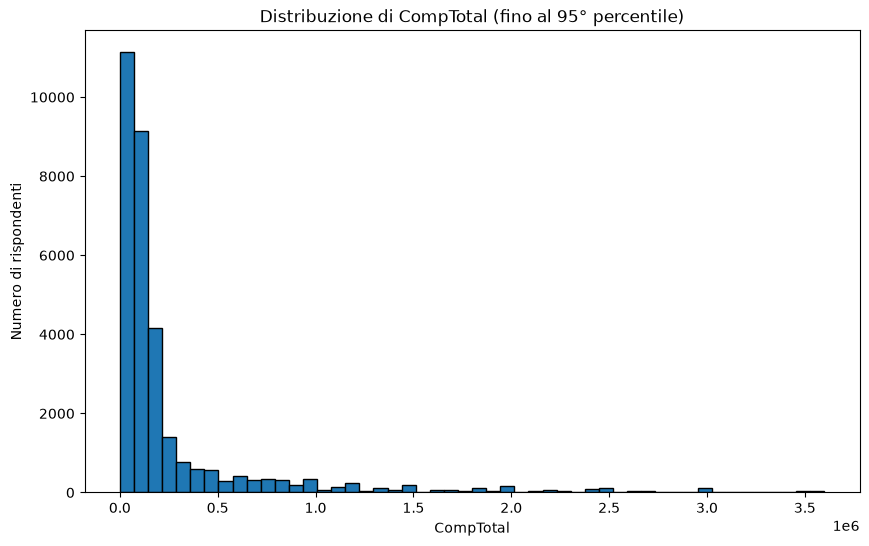

In [9]:
conn = sqlite3.connect('/tmp/survey-data.sqlite')
QUERY = """
SELECT CompTotal
FROM main
WHERE CompTotal IS NOT NULL
"""
df_comp = pd.read_sql_query(QUERY, conn)


limit = df_comp['CompTotal'].quantile(0.95)
df_plot = df_comp[df_comp['CompTotal'] <= limit]


plt.figure(figsize=(10, 6))
plt.hist(df_plot['CompTotal'], bins=50, edgecolor='black')
plt.title('Distribution of CompTotal (up to the 95th percentile)')
plt.xlabel('CompTotal')
plt.ylabel('Number of Respondents')
plt.show()

**Box Plots**

Plot a box plot of Age.


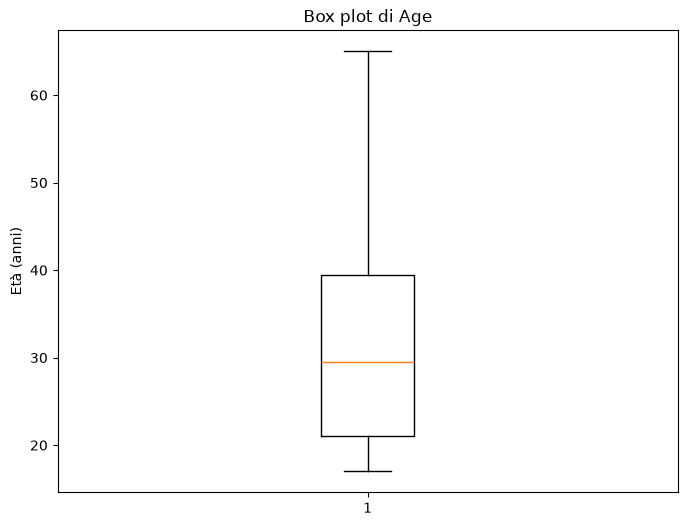

In [12]:
conn = sqlite3.connect('/tmp/survey-data.sqlite')
QUERY = "SELECT Age FROM main WHERE Age IS NOT NULL"
df_age = pd.read_sql_query(QUERY, conn)

# Age is text (ranges): convert it to the midpoint of each range
age_map = {'Under 18 years old': 17, '18-24 years old': 21, '25-34 years old': 29.5, '35-44 years old': 39.5, '45-54 years old': 49.5, '55-64 years old': 59.5, '65 years or older': 65}
df_age['AgeNum'] = df_age['Age'].map(age_map)
df_age = df_age.dropna(subset=['AgeNum'])

plt.figure(figsize=(8, 6))
plt.boxplot(df_age['AgeNum'])
plt.title('Box Plot of Age')
plt.ylabel('Age (years)')
plt.show()

### Visualizing Relationships in Data

**Scatter Plots**

Create a scatter plot of Age and WorkExp.


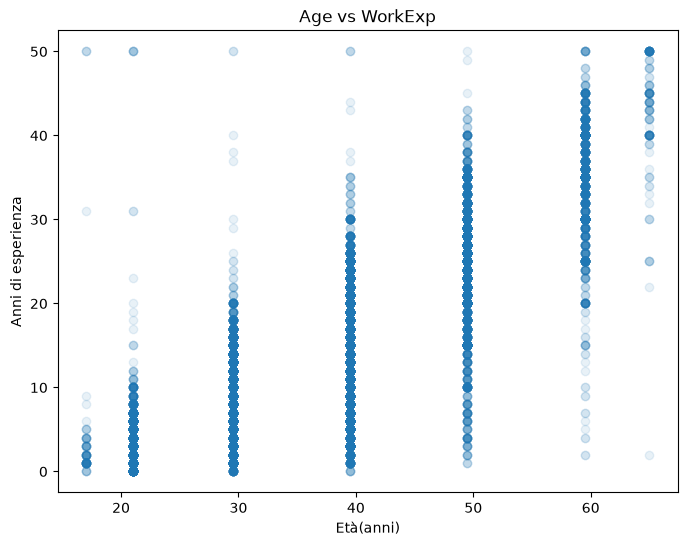

In [15]:
conn = sqlite3.connect('/tmp/survey-data.sqlite')
QUERY = " SELECT Age, WorkExp FROM main WHERE Age IS NOT NULL AND WorkExp IS NOT NULL"
df_scatter= pd.read_sql_query(QUERY, conn)

age_map = {'Under 18 years old': 17, '18-24 years old': 21, '25-34 years old': 29.5, '35-44 years old': 39.5, '45-54 years old': 49.5, '55-64 years old': 59.5, '65 years or older': 65} 
df_scatter['AgeNum']=df_scatter['Age'].map(age_map)
df_scatter= df_scatter.dropna(subset=['AgeNum']) 
plt.figure(figsize=(8, 6))
plt.scatter(x =df_scatter['AgeNum'], y= df_scatter['WorkExp'], alpha=0.1)
plt.title("Age vs WorkExp")
plt.xlabel("Age (years)")
plt.ylabel("Years of Work Experience")
plt.show()

**Bubble Plots**

Create a bubble plot of `TimeSearching` and `Frustration` using the Age column as the bubble size.


**Approach:** `TimeSearching` and `Age` are text ranges, mapped to their midpoints; `Frustration` is multi-select and is exploded to one row per answer.

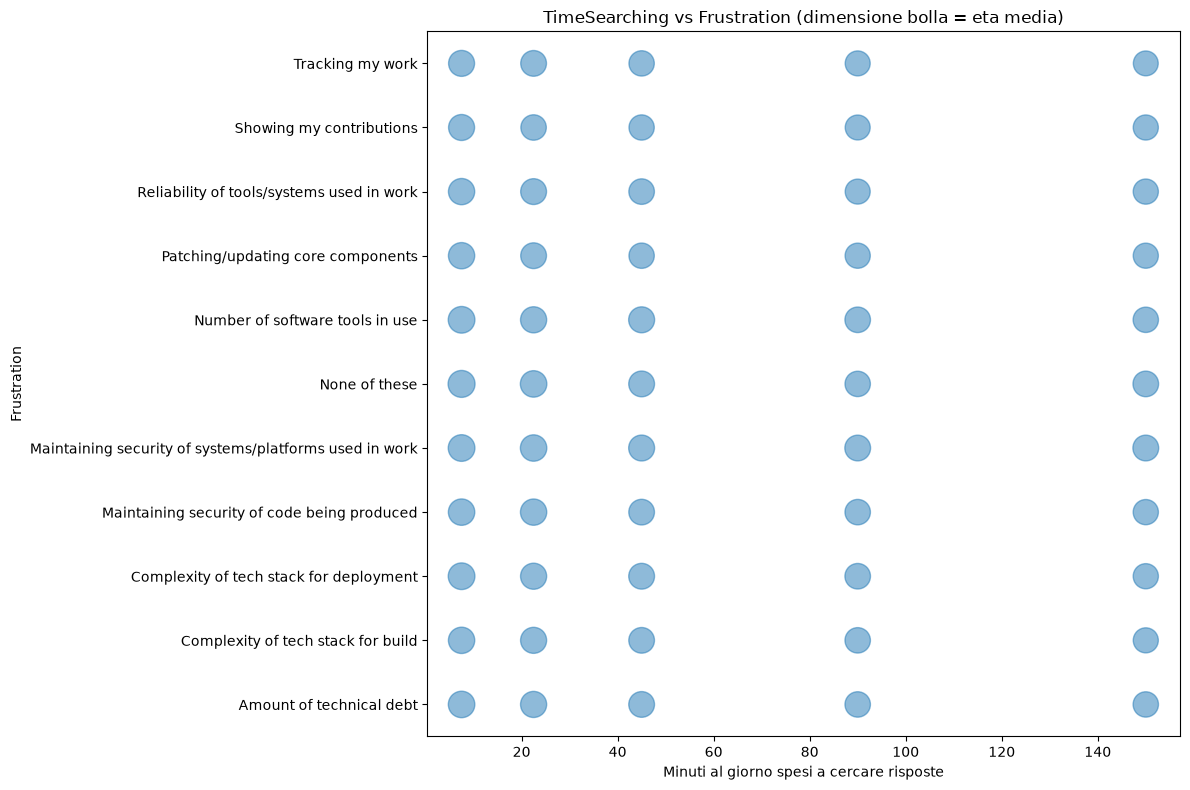

In [16]:
conn = sqlite3.connect('/tmp/survey-data.sqlite')
QUERY = "SELECT TimeSearching, Frustration, Age FROM main WHERE TimeSearching IS NOT NULL AND Frustration IS NOT NULL AND Age IS NOT NULL"
df_bub = pd.read_sql_query(QUERY, conn)

# TimeSearching and Age are text ranges: convert them to the midpoint
time_map = {'Less than 15 minutes a day': 7.5, '15-30 minutes a day': 22.5, '30-60 minutes a day': 45, '60-120 minutes a day': 90, 'Over 120 minutes a day': 150}
df_bub['TimeMin'] = df_bub['TimeSearching'].map(time_map)
df_bub['AgeNum'] = df_bub['Age'].map(age_map)
df_bub = df_bub.dropna(subset=['TimeMin', 'AgeNum'])

# Frustration has multiple answers separated by ';': one row per answer
df_bub['Frustration'] = df_bub['Frustration'].str.split(';')
df_bub = df_bub.explode('Frustration')

# Mean age for each time-frustration pair
df_group = df_bub.groupby(['TimeMin', 'Frustration'])['AgeNum'].mean().reset_index()

plt.figure(figsize=(12, 8))
plt.scatter(df_group['TimeMin'], df_group['Frustration'], s=df_group['AgeNum'] * 10, alpha=0.5)
plt.title('TimeSearching vs Frustration (bubble size = mean age)')
plt.xlabel('Minutes per day spent searching for answers')
plt.ylabel('Frustration')
plt.tight_layout()
plt.show()

### Visualizing Composition of Data

**Pie Charts**

Create a pie chart of the top 5 databases(`DatabaseWantToWorkWith`) that respondents wish to learn next year.


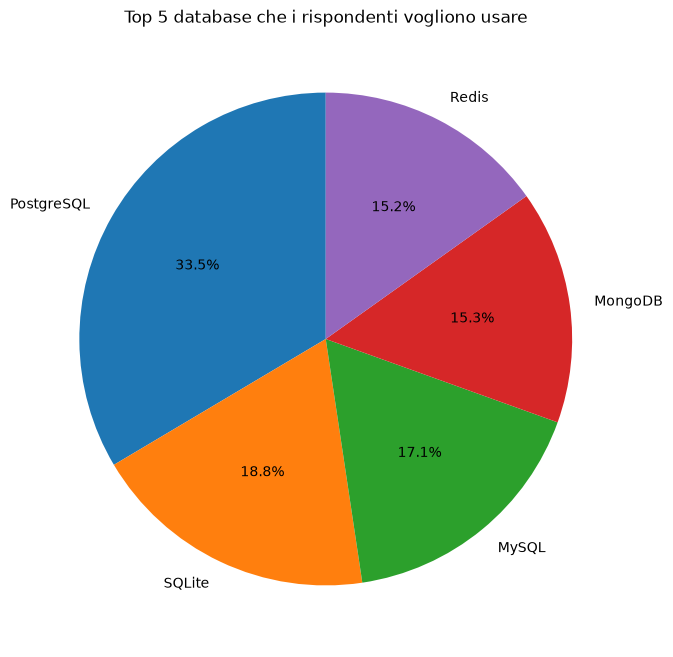

In [17]:
conn = sqlite3.connect('/tmp/survey-data.sqlite')
QUERY = "SELECT DatabaseWantToWorkWith FROM main WHERE DatabaseWantToWorkWith IS NOT NULL"
df_db = pd.read_sql_query(QUERY, conn)

# Multiple databases per answer separated by ';': split, explode and count
top5 = df_db['DatabaseWantToWorkWith'].str.split(';').explode().value_counts().head(5)

plt.figure(figsize=(8, 8))
plt.pie(top5, labels=top5.index, autopct='%1.1f%%', startangle=90)
plt.title('Top 5 Databases Respondents Want to Work With')
plt.show()

**Stacked Charts** 

Create a stacked bar chart of median `TimeSearching` and `TimeAnswering` for the age group 30 to 35.


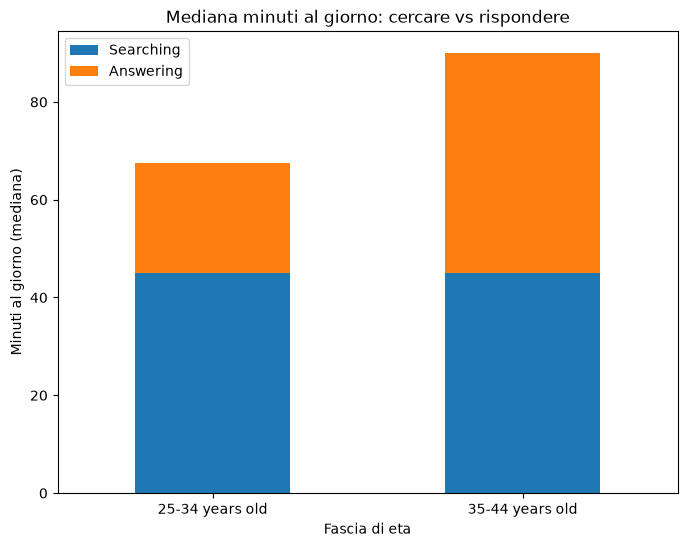

In [18]:
conn = sqlite3.connect('/tmp/survey-data.sqlite')
QUERY = "SELECT Age, TimeSearching, TimeAnswering FROM main WHERE TimeSearching IS NOT NULL AND TimeAnswering IS NOT NULL AND Age IN ('25-34 years old', '35-44 years old')"
df_st = pd.read_sql_query(QUERY, conn)

# The survey has no 30-35 range: use the two ranges that cover it (25-34 and 35-44)
df_st['Searching'] = df_st['TimeSearching'].map(time_map)
df_st['Answering'] = df_st['TimeAnswering'].map(time_map)
df_st = df_st.dropna(subset=['Searching', 'Answering'])

medians = df_st.groupby('Age')[['Searching', 'Answering']].median()

medians.plot(kind='bar', stacked=True, figsize=(8, 6))
plt.title('Median Minutes per Day: Searching vs Answering')
plt.xlabel('Age Group')
plt.ylabel('Minutes per Day (median)')
plt.xticks(rotation=0)
plt.show()

### Visualizing Comparison of Data

**Line Chart**

Plot the median `CompTotal` for all ages from 45 to 60.


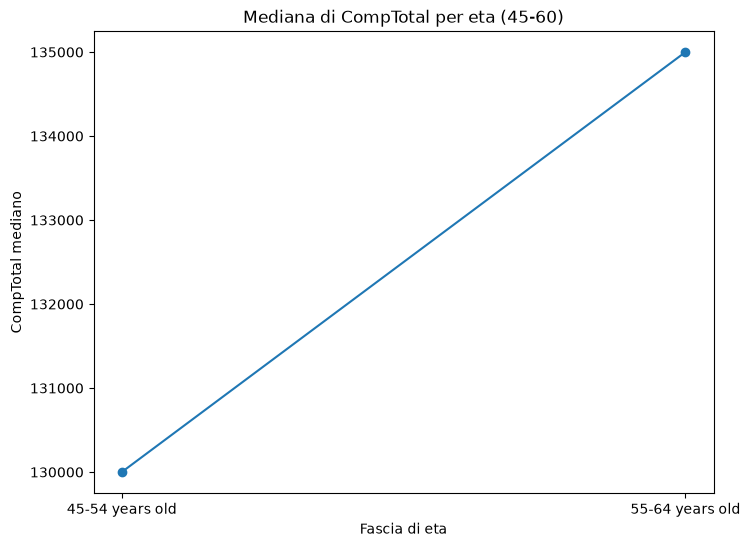

In [19]:
conn = sqlite3.connect('/tmp/survey-data.sqlite')
QUERY = "SELECT Age, CompTotal FROM main WHERE CompTotal IS NOT NULL AND Age IN ('45-54 years old', '55-64 years old')"
df_line = pd.read_sql_query(QUERY, conn)

# The ranges covering 45-60 are 45-54 and 55-64: median CompTotal per range
median_comp = df_line.groupby('Age')['CompTotal'].median()

plt.figure(figsize=(8, 6))
plt.plot(median_comp.index, median_comp.values, marker='o')
plt.title('Median CompTotal by Age (45-60)')
plt.xlabel('Age Group')
plt.ylabel('Median CompTotal')
plt.show()

**Bar Chart**

Create a horizontal bar chart using the `MainBranch` column.


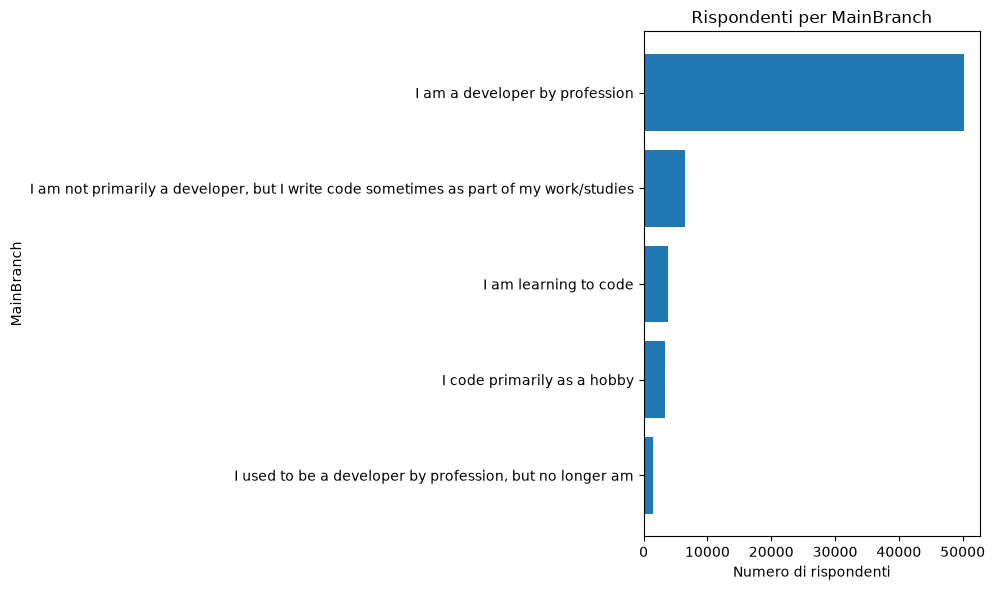

In [20]:
conn = sqlite3.connect('/tmp/survey-data.sqlite')
QUERY = "SELECT MainBranch, COUNT(*) AS Count FROM main WHERE MainBranch IS NOT NULL GROUP BY MainBranch ORDER BY Count"
df_branch = pd.read_sql_query(QUERY, conn)

plt.figure(figsize=(10, 6))
plt.barh(df_branch['MainBranch'], df_branch['Count'])
plt.title('Respondents by MainBranch')
plt.xlabel('Number of Respondents')
plt.ylabel('MainBranch')
plt.tight_layout()
plt.show()

### Summary


In this lab, you focused on extracting and visualizing data from an RDBMS using SQL queries and SQLite. You applied various visualization techniques, including:

- Histograms to display the distribution of CompTotal.
- Box plots to show the spread of ages.
- Scatter plots and bubble plots to explore relationships between variables like Age, WorkExp, `TimeSearching` and `TimeAnswering`.
- Pie charts and stacked charts to visualize the composition of data.
- Line charts and bar charts to compare data across categories.


### Close the Database Connection

Once the lab is complete, ensure to close the database connection:


In [21]:
conn.close()

## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
